In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("benjaminmcgregor/german-credit-data-set-with-credit-risk")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Wagner Kataoka\.cache\kagglehub\datasets\benjaminmcgregor\german-credit-data-set-with-credit-risk\versions\1


## 1. Carregando os Dados

In [41]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.offline as py
import plotly.tools as tls

In [42]:
# Criando um DataFrame com os dados do arquivo CSV
df = pd.read_csv("german_credit_data_updated.csv")

# Exibindo as primeiras linhas do DataFrame
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


 ## 2. AED - Análise Exploratória dos Dados

In [43]:
# Exibindo informações gerais sobre o DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        954 non-null    int64 
 1   Age               954 non-null    int64 
 2   Sex               954 non-null    object
 3   Job               954 non-null    int64 
 4   Housing           954 non-null    object
 5   Saving accounts   779 non-null    object
 6   Checking account  576 non-null    object
 7   Credit amount     954 non-null    int64 
 8   Duration          954 non-null    int64 
 9   Purpose           954 non-null    object
 10  Credit Risk       954 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 82.1+ KB


In [44]:
# Removendo a coluna "Unnamed: 0" do DataFrame
df = df.drop(columns=["Unnamed: 0"], axis=1)

# Exibindo as primeiras linhas do DataFrame após a remoção da coluna
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,49,male,1,own,little,NaN,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,2


In [45]:
# Preenchndo valores ausentes na coluna "Saving accounts"
df["Saving accounts"] = df["Saving accounts"].fillna("unknown")

# Preenchndo valores ausentes na coluna "Checking account"
df["Checking account"] = df["Checking account"].fillna("unknown")

# Verificando novamente a presença de valores ausentes no DataFrame
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Credit Risk         0
dtype: int64

 ### 2.1. Perfil Geral dos Clientes

In [46]:
# Estatísticas numéricas do DataFrame
df.describe()

,Age,Job,Credit amount,Duration,Credit Risk
count,954.000000,954.000000,954.000000,954.000000,954.000000
mean,35.501048,1.909853,3279.112159,20.780922,1.302935
std,11.379668,0.649681,2853.315158,12.046483,0.459768
min,19.000000,0.000000,250.000000,4.000000,1.000000
25%,27.000000,2.000000,1360.250000,12.000000,1.000000
50%,33.000000,2.000000,2302.500000,18.000000,1.000000
75%,42.000000,2.000000,3975.250000,24.000000,2.000000
max,75.000000,3.000000,18424.000000,72.000000,2.000000


Analisando os dados numéricos do DataFrame, podemos concluir que:
- A maior parte dos clientes tem até 42 anos de idade
- O cliente mais novo possui 19 anos e o mais velho 75 anos
- Em relação ao trabalho, a maior parte dos clientes faz parte do perfil 2 (skilled)
- Em relação à quantidade de crédito, a maior parte dos clientes tem um crédito de até $3972.25
- Em média, as pessoas ganham um crédito de $3279.11
- A maioria dos clientes tem uma duração de empréstimo de até 24 meses, com uma duração média de 20 meses
- Observando a média do risco do crédito (1,30), podemos concluir que a maior parte dos clientes são bons pagadores (1 indicando uma boa pontuação de crédito e 2 uma má pontuação)

In [47]:
# Contagem de valores únicos em cada coluna categórica
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    print(f"Contagem de valores únicos na coluna '{col}':")
    print(df[col].value_counts())
    print()


Contagem de valores únicos na coluna 'Sex':
Sex
male      656
female    298
Name: count, dtype: int64

Contagem de valores únicos na coluna 'Housing':
Housing
own     680
rent    169
free    105
Name: count, dtype: int64

Contagem de valores únicos na coluna 'Saving accounts':
Saving accounts
little        576
unknown       175
moderate       96
quite rich     60
rich           47
Name: count, dtype: int64

Contagem de valores únicos na coluna 'Checking account':
Checking account
unknown     378
little      261
moderate    256
rich         59
Name: count, dtype: int64

Contagem de valores únicos na coluna 'Purpose':
Purpose
car                    322
radio/TV               262
furniture/equipment    175
business                93
education               58
repairs                 20
domestic appliances     12
vacation/others         12
Name: count, dtype: int64



Analisando as variáveis categóricas, podemos concluir que:
- Homens são maioria, são 656 homens e 298 mulheres
- A grande maioria possui casa própria
- A maior parte dos clientes possui pouco dinheiro em poupança
- Há uma quantidade razoável de clientes que não possuem poupança (175 de 954)
- Grande parte dos clientes não possuem conta corrente
- Dos clientes que possuem conta corrente, a maioria possui uma quantidade pequena ou moderada de dinehiro em conta
- Os três principais motivos para solicitar um empréstimo são: 
    1. Carro
    2. Aparelhos de rádio ou TV
    3. Móveis ou equipamentos


 ### 2.2. Analisando o Crédito

C:\Users\Wagner Kataoka\AppData\Local\Temp\ipykernel_9652\1369918557.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




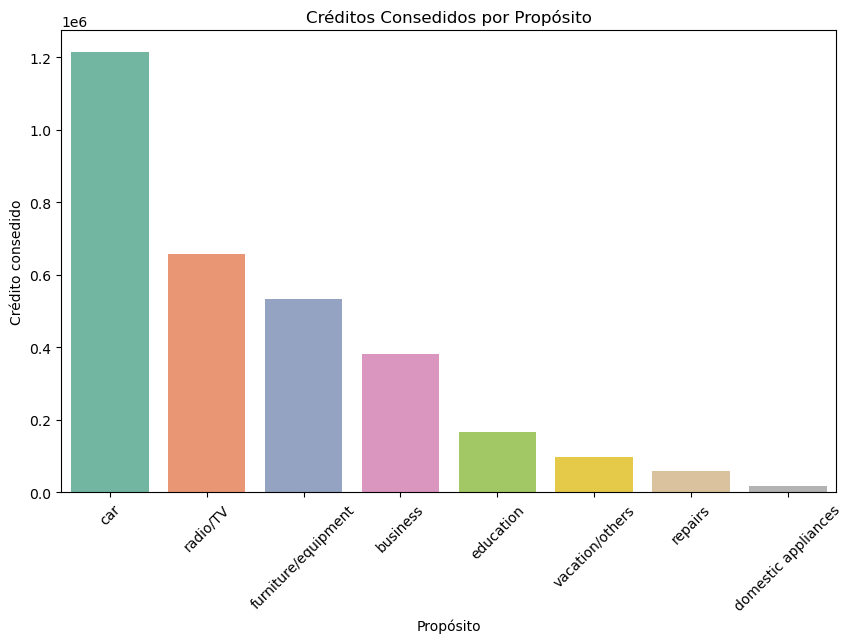

In [48]:
# Agrupando por 'Propósito' e calculando a quantidade de 'Crédito sedido' para cada propósito
purpose_group = df.groupby('Purpose')['Credit amount'].sum().reset_index()
purpose_group = purpose_group.sort_values(by='Credit amount', ascending=False)

# Visualizando os dados agrupados
plt.figure(figsize=(10, 6))
sns.barplot(data=purpose_group, x='Purpose', y='Credit amount', palette='Set2')
plt.title('Créditos Consedidos por Propósito')
plt.xlabel('Propósito')
plt.ylabel('Crédito consedido')
plt.xticks(rotation=45)
plt.show()

In [49]:
# Função para criar boxplots
def boxes(x,y,h,r=45):
    fig, ax = plt.subplots(figsize=(10,6))
    box = sns.boxplot(x=x,y=y, hue=h, data=df)
    box.set_xticklabels(box.get_xticklabels(), rotation=r)
    fig.subplots_adjust(bottom=0.2)
    plt.tight_layout()

C:\Users\Wagner Kataoka\AppData\Local\Temp\ipykernel_9652\1263535816.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



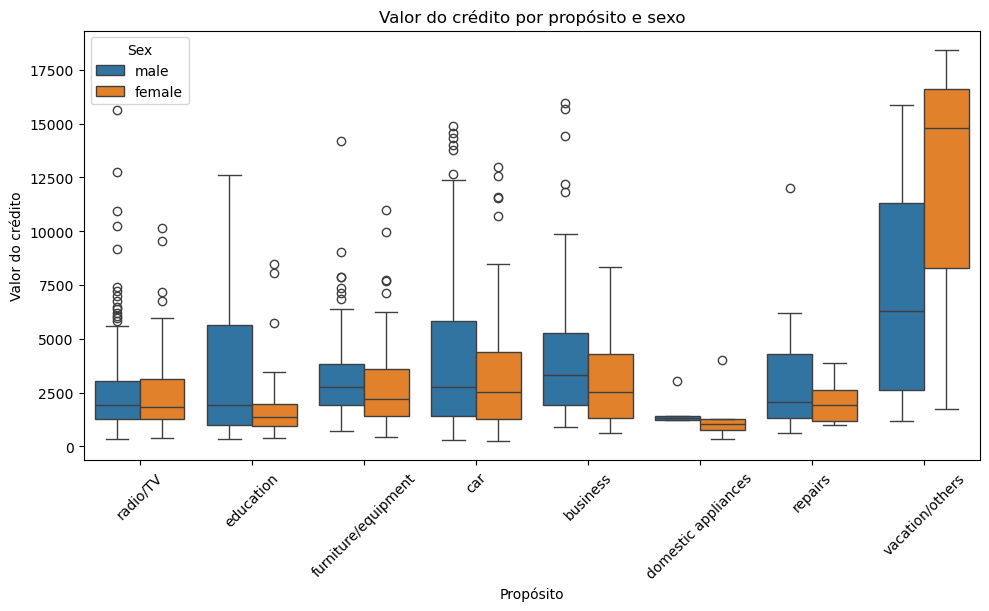

In [50]:
# Exibindo boxplots do valor do crédito por propósito e sexo
boxes("Purpose","Credit amount","Sex")
plt.title("Valor do crédito por propósito e sexo")
plt.ylabel("Valor do crédito")
plt.xlabel("Propósito")
plt.show()

Analisando esse diagrama de caixa, podemos concluir que:
- No geral, homens costumam pedir valores maiores de crédito do que as mulheres
- Os maiores valores são destinados a férias/outros e os menores a eletrodomésticos
- Apesar dos maiores valores serem destinados a férias e outros, o valor de crédito concedido nessa categoria foi muito baixo.

C:\Users\Wagner Kataoka\AppData\Local\Temp\ipykernel_9652\1263535816.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



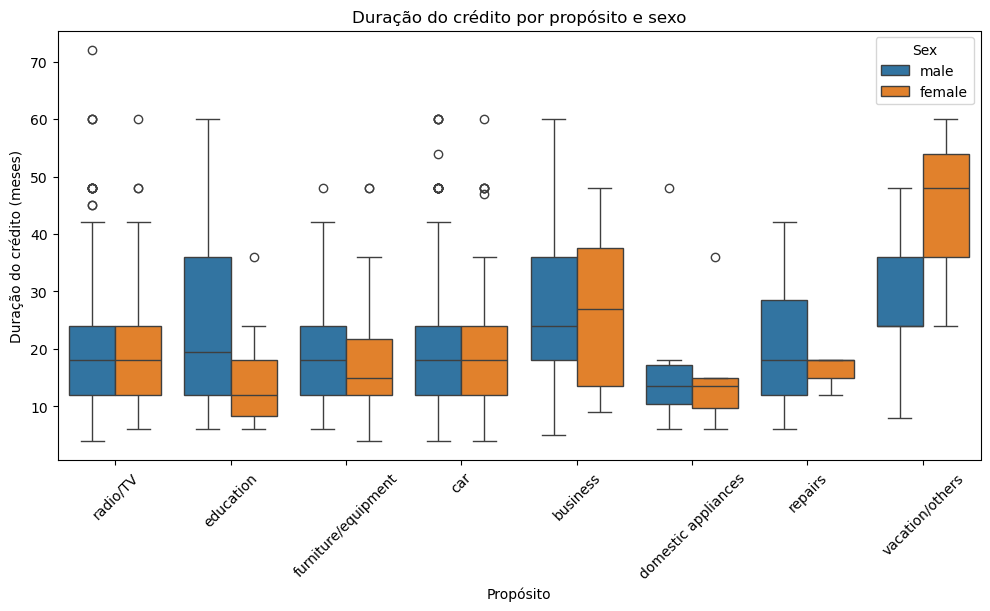

In [51]:
# Exibindo boxplots da duração do crédito por propósito e sexo
boxes("Purpose","Duration","Sex")
plt.title("Duração do crédito por propósito e sexo")
plt.ylabel("Duração do crédito (meses)")
plt.xlabel("Propósito")
plt.show()

Relacionando esse diagrama de caixa com o diagrama de caixa anterior, a duração de crédito parece ter um relação com o valor do crédito. Quanto maior o valor, maior a duração do crédito

C:\Users\Wagner Kataoka\AppData\Local\Temp\ipykernel_9652\1263535816.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



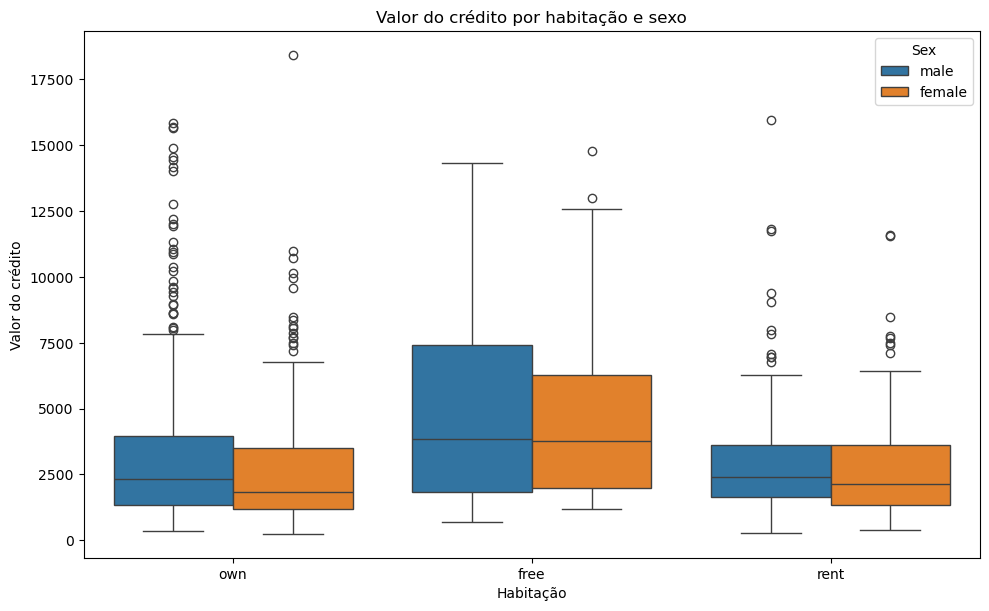

In [52]:
# Exibindo boxplots do valor do crédito por habitação e sexo
boxes("Housing","Credit amount","Sex",r=0)
plt.title("Valor do crédito por habitação e sexo")
plt.ylabel("Valor do crédito")
plt.xlabel("Habitação")
plt.show()

Observando esse diagrama de caixa, podemos concluir que pessoas que não possuem habitação, tendem a solicitar créditos ligeiramente maiores 

C:\Users\Wagner Kataoka\AppData\Local\Temp\ipykernel_9652\1263535816.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



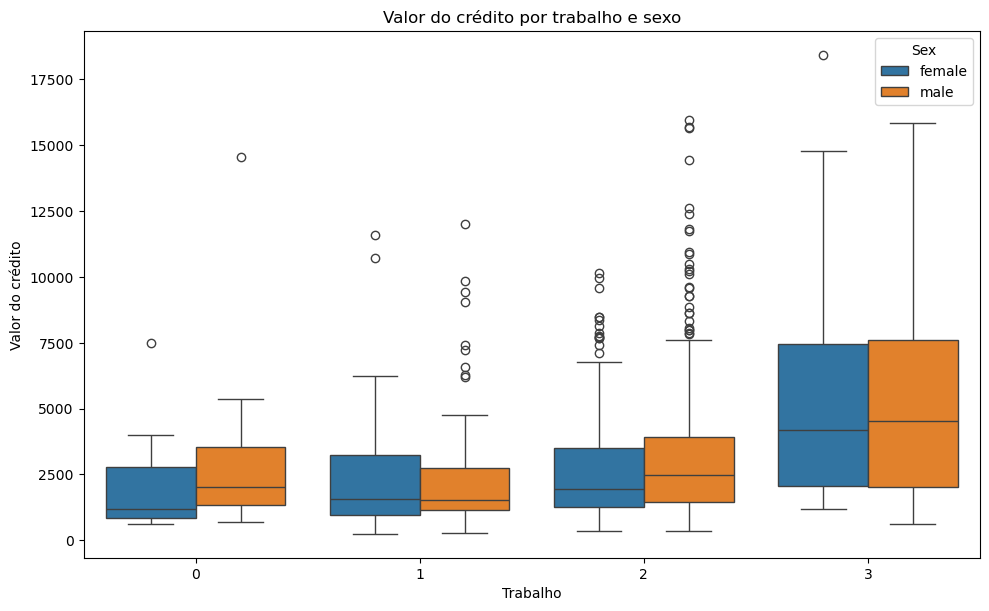

C:\Users\Wagner Kataoka\AppData\Local\Temp\ipykernel_9652\1263535816.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



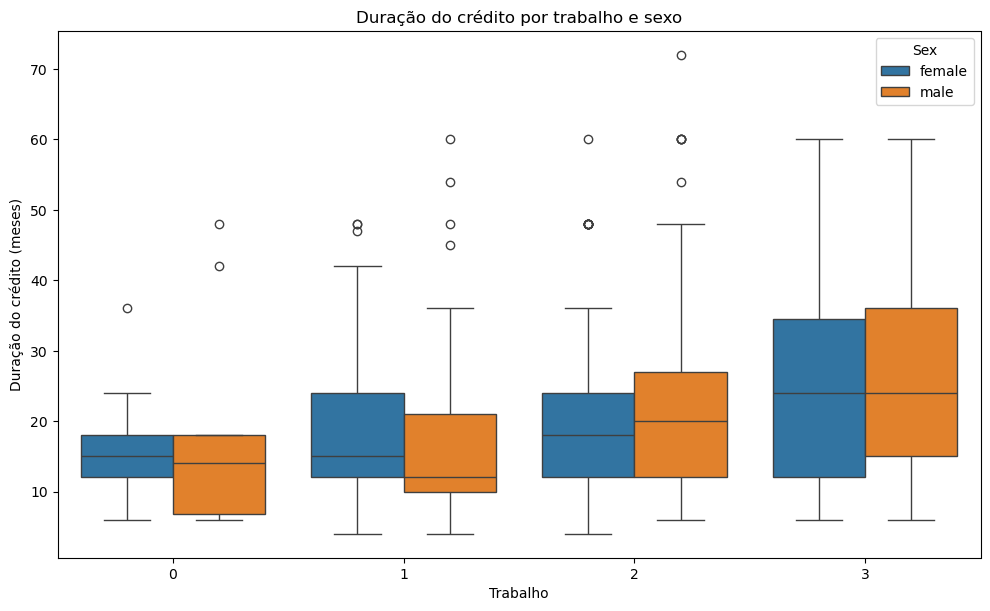

In [53]:
# Exibindo boxplots do valor do crédito por trabalho e sexo
boxes("Job","Credit amount","Sex",r=0)
plt.title("Valor do crédito por trabalho e sexo")
plt.ylabel("Valor do crédito")
plt.xlabel("Trabalho")
plt.show()

# Exibindo boxplots da duração do crédito por trabalho e sexo
boxes("Job","Duration","Sex",r=0)
plt.title("Duração do crédito por trabalho e sexo")
plt.ylabel("Duração do crédito (meses)")
plt.xlabel("Trabalho")
plt.show()

Em relação ao trabalho, podemos concluir que:
- Mulheres tendem a pedir valores de crédito um pouco maiores que os homens, com exceção das mulheres da categoria 1 (não capacitada e com resisdência), que tendem a pedir valores de crédito ligeiramente menores que os homens dessa mesma categoria
- Pessoas da categoria 3 (altamente capacitados) tendem a solicitar valores de crédito maiores por períodos mais longos.

 ### 2.3. Analisando o Risco de Crédito

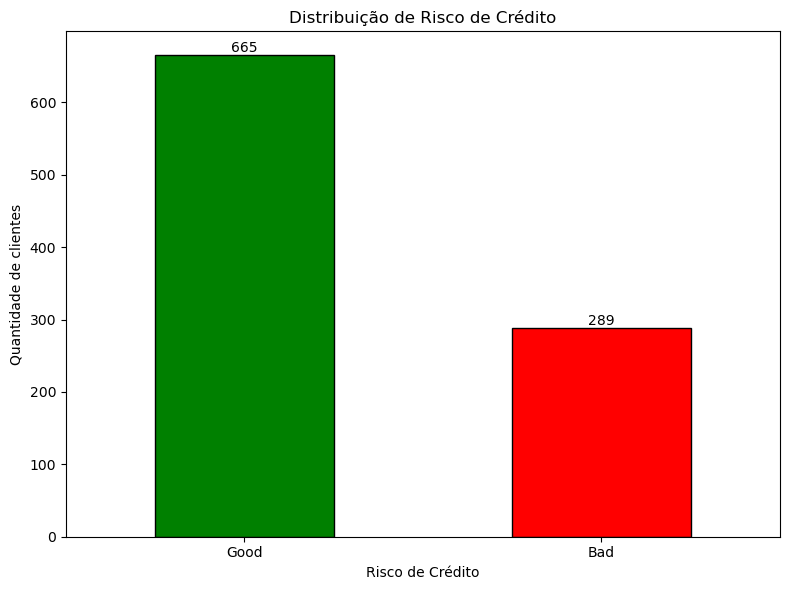

In [54]:
# Plotando um gráfico de distribuição de risco de crédito
plt.figure(figsize=(8, 6))
contagem = df['Credit Risk'].replace({1: 'Good', 2: 'Bad'}).value_counts()
ax = contagem.plot(kind='bar', color=['green', 'red'],edgecolor='black')

# Adicionando valores nas barras
for i, v in enumerate(contagem):
    ax.text(i, v, str(v), ha='center', va='bottom')

# Configurações do gráfico
plt.title('Distribuição de Risco de Crédito')
plt.xlabel('Risco de Crédito')
plt.ylabel('Quantidade de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

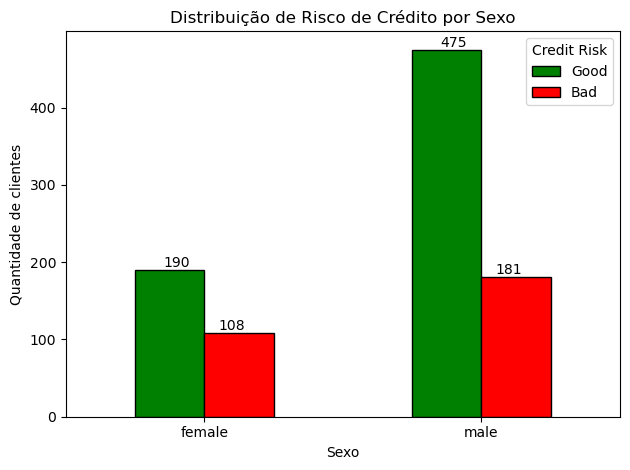

In [55]:
# Plotando um gráfico de distribuição de risco de crédito por sexo
plt.figure(figsize=(8, 6))
contagem_sexo = df.groupby('Sex')['Credit Risk'].value_counts().unstack()
contagem_sexo = contagem_sexo.rename(columns={1: 'Good', 2: 'Bad'})
ax_1 = contagem_sexo.plot(kind='bar', color=['green', 'red'],edgecolor='black')

# Adicionando valores nas barras
for i in range(len(contagem_sexo)):
    for j, v in enumerate(contagem_sexo.iloc[i]):
        ax_1.text(i + j*0.2 - 0.1, v, str(v), ha='center', va='bottom')

# Configurações do gráfico
plt.title('Distribuição de Risco de Crédito por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
# Calculando a porcentagem de clientes com risco de crédito ruim por sexo
porcentagem_risco_ruim = df.groupby('Sex')['Credit Risk'].apply(lambda x: (x == 2).mean() * 100)
porcentagem_risco_ruim = porcentagem_risco_ruim.rename('% de Risco Ruim')
porcentagem_risco_ruim = porcentagem_risco_ruim.round(2)
display(porcentagem_risco_ruim)

Sex
female    36.24
male      27.59
Name: % de Risco Ruim, dtype: float64

Analisando a distribuição de risco de crédito por sexo, observamos que há mais homens do que mulheres classificados como maus pagadores. Porém, ao observar isoladamente o percentual de homens e mulheres, vemos que as mulheres tem um porcentual de risco de crédito ruim ligeiramente mais alto que os homens

In [57]:
# Filtrando os dados para plotagem
df_good = df.loc[df["Credit Risk"] == 1]['Age'].values.tolist()
df_bad = df.loc[df["Credit Risk"] == 2]['Age'].values.tolist()
df_age = df['Age'].values.tolist()

# Primeiro plot
trace0 = go.Histogram(
    x=df_good,
    histnorm='probability',
    name="Risco de crédito bom"
)
# Segundo plot
trace1 = go.Histogram(
    x=df_bad,
    histnorm='probability',
    name="Risco de crédito ruim"
)
# Terceiro plot
trace2 = go.Histogram(
    x=df_age,
    histnorm='probability',
    name="Geral"
)

# Criando a grade
fig = tls.make_subplots(rows=2, cols=2, specs=[[{}, {}], [{'colspan': 2}, None]],
                          subplot_titles=('Risco de crédito bom','Risco de crédito ruim', 'Distribuição geral da idade'))

# Montando os plots na grade
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig.append_trace(trace2, 2, 1)

fig['layout'].update(showlegend=True, title='Distribuição da idade', bargap=0.05)
py.iplot(fig, filename='custom-sized-subplot-with-subplot-titles')

c:\Users\Wagner Kataoka\anaconda3\Lib\site-packages\plotly\tools.py:455: DeprecationWarning:

plotly.tools.make_subplots is deprecated, please use plotly.subplots.make_subplots instead



Observando os histogramas de distribuição de idade, podemos concluir que:
- A maioria das pessoas classificadas como bom risco de crédito, ficam em um faixa etária que vai de 22 a 37 anos
- A maioria das pessoas classificadas como risco de crédito ruim, ficam em um faixa etária que vai de 20 a 34 anos
- Cerca de 25% dos maus pagadores tem entre 25 a 29 anos
- No geral, a maioria dos clientes tem entre 22 a 37 anos 


In [58]:
# Criando uma coluna de categorias de idade no DataFrame
interval = (19, 40, 60, 75)

cats = ['Adult', 'Middle Age', 'Senior']
df["Age_cat"] = pd.cut(df.Age, interval, labels=cats)

display(df.head())

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk,Age_cat
0,67,male,2,own,unknown,little,1169,6,radio/TV,1,Senior
1,22,female,2,own,little,moderate,5951,48,radio/TV,2,Adult
2,49,male,1,own,little,unknown,2096,12,education,1,Middle Age
3,45,male,2,free,little,little,7882,42,furniture/equipment,1,Middle Age
4,53,male,2,free,little,little,4870,24,car,2,Middle Age


In [59]:
# Separando os dados em dois DataFrames com base no risco de crédito
df_good_credit = df[df["Credit Risk"] == 1]
df_bad_credit = df[df["Credit Risk"] == 2]

# Plotando boxplots do valor do crédito por categoria de idade e risco de crédito
trace0 = go.Box(
    y=df_good_credit["Credit amount"],
    x=df_good_credit["Age_cat"],
    name='Good credit',
    marker=dict(
        color='#3D9970'
    )
)

trace1 = go.Box(
    y=df_bad_credit['Credit amount'],
    x=df_bad_credit['Age_cat'],
    name='Bad credit',
    marker=dict(
        color='#FF4136'
    )
)
    
data = [trace0, trace1]

layout = go.Layout(
    title='Valor do Crédito por Categoria de Idade e Risco de Crédito',
    yaxis=dict(
        title='Valor do Crédito',
        zeroline=False
    ),
    xaxis=dict(
        title='Categoria de Idade'
    ),
    boxmode='group'
)
fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='box-age-cat')

Analisando esse diagrama de caixa, é possível perceber que:
- Pessoas com risco de crédito ruim possuem quantidade de crédito maiores
- A maior parte dos bons pagadores, possuem créditos abaixo de $4000
- As caixas dos bons pagadores possuem valores similares

In [60]:
# Contagem de  valores únicos na coluna "Housing"
total_housing = df["Housing"].value_counts()

# Plotando gráfico de barras para a coluna "Housing"
trace = go.Bar(
    x = total_housing.index.values,
    y = total_housing.values,
    marker=dict(
        color=['#1f77b4', '#ff7f0e', '#2ca02c'],
        line=dict(color='rgb(8,48,107)', width=1.5)
    )
)
data = [trace]
layout = go.Layout(
    title='Distribuição de Habitação',
    xaxis=dict(title='Housing'),
    yaxis=dict(title='Count')
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='Housing Distribution')

In [61]:
# Plotando gráfico de barras agrupadas para a coluna "Housing" com base no risco de crédito
trace0 = go.Bar(
    x = df[df["Credit Risk"]== 1]["Housing"].value_counts().index.values,
    y = df[df["Credit Risk"]== 1]["Housing"].value_counts().values,
    name='Good credit'
)

trace1 = go.Bar(
    x = df[df["Credit Risk"]== 2]["Housing"].value_counts().index.values,
    y = df[df["Credit Risk"]== 2]["Housing"].value_counts().values,
    name="Bad Credit"
)

data = [trace0, trace1]

layout = go.Layout(
    title='Distribuição de Habitação por Risco de Crédito',
)


fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='Housing-Grouped')

Após observar os gráficos, podemos perceber que pessoas com casa prórpia constituem a grande maioria dos clientes com crédito de risco positivo. De todas as categorias de habitação, a que mais se destaca é a de "possui casa própria", tanto pelo número total de pessoas nessa categoria, quanto pela relação muito mais positiva entre o risco de crédito (cerca de 73,5% de risco positivo)

In [62]:
# Plotando gráfico de barras agrupadas para a coluna "Job" com base no risco de crédito
trace0 = go.Bar(
    x = df[df["Credit Risk"]== 1]["Job"].value_counts().index.values,
    y = df[df["Credit Risk"]== 1]["Job"].value_counts().values,
    name='Good credit'
)

trace1 = go.Bar(
    x = df[df["Credit Risk"]== 2]["Job"].value_counts().index.values,
    y = df[df["Credit Risk"]== 2]["Job"].value_counts().values,
    name="Bad Credit"
)

data = [trace0, trace1]

layout = go.Layout(
    title='Distribuição de Trabalho por Risco de Crédito',
)


fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='Housing-Grouped')

In [63]:
# Calculando a porcentagem de clientes com risco de crédito ruim por profissão
pct_risco_ruim_por_trabalho = df.groupby('Job')['Credit Risk'].apply(lambda x: (x == 2).mean() * 100)
pct_risco_ruim_por_trabalho_risco_ruim = pct_risco_ruim_por_trabalho.rename('% de Risco Ruim')
pct_risco_ruim_por_trabalho = pct_risco_ruim_por_trabalho_risco_ruim.round(2)
display(pct_risco_ruim_por_trabalho)

Job
0    28.57
1    28.65
2    29.65
3    35.46
Name: % de Risco Ruim, dtype: float64

In [64]:
# Plotando boxplots do valor do crédito por trabalho e risco de crédito
trace0 = go.Box(
    x=df_good_credit["Job"],
    y=df_good_credit["Credit amount"],
    name='Good credit'
)

trace1 = go.Box(
    x=df_bad_credit['Job'],
    y=df_bad_credit['Credit amount'],
    name='Bad credit'
)
    
data = [trace0, trace1]

layout = go.Layout(
    title='Valor do Crédito por Trabalho e Risco de Crédito',
    yaxis=dict(
        title='Valor do Crédito',
        zeroline=False
    ),
    xaxis=dict(
        title='Tipo de trabalho'
    ),
    boxmode='group'
)

fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='box-job-credit')

Ao analisar os gráficos, podemos concluir que:
- O perfil predominante na base é a Categoria 2 ("qualificado/skilled").
- Contudo, os maiores limites de crédito são concedidos aos clientes da Categoria 3 ("altamente qualificado/highly skilled").
- A Categoria 3 também apresenta a maior taxa de inadimplência, correspondendo a 35,46% dos indivíduos desse grupo.

In [65]:
# Plotando gráfico de barras agrupadas para a coluna "Saving accounts" com base no risco de crédito
trace0 = go.Bar(
    x = df[df["Credit Risk"]== 1]["Saving accounts"].value_counts().index.values,
    y = df[df["Credit Risk"]== 1]["Saving accounts"].value_counts().values,
    name='Good credit'
)

trace1 = go.Bar(
    x = df[df["Credit Risk"]== 2]["Saving accounts"].value_counts().index.values,
    y = df[df["Credit Risk"]== 2]["Saving accounts"].value_counts().values,
    name="Bad Credit"
)

data = [trace0, trace1]

layout = go.Layout(
    title='Distribuição de Contas de Poupança por Risco de Crédito',
)


fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='Saving-Accounts-Grouped')

In [66]:
# Plotando boxplots do valor do crédito por contas de poupança e risco de crédito
trace0 = go.Box(
    x=df_good_credit["Saving accounts"],
    y=df_good_credit["Credit amount"],
    name='Good credit'
)

trace1 = go.Box(
    x=df_bad_credit['Saving accounts'],
    y=df_bad_credit['Credit amount'],
    name='Bad credit'
)
    
data = [trace0, trace1]

layout = go.Layout(
    title='Valor do Crédito por Contas de Poupança e Risco de Crédito',
    yaxis=dict(
        title='Valor do Crédito',
        zeroline=False
    ),
    xaxis=dict(
        title='Valor da Conta de Poupança'
    ),
    boxmode='group'
)

fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='box-saving-accounts-credit')

Analisando os gráficos, podemos observar que:
- A maior parte dos clientes possuem pouco dinheiro em poupança
- Há uma quantidade significativa de clientes sem informação de conta, elas devem ser de pessoas que não possuem esse tipo de conta na instituição
- Os maiores valores de crédito são destinados as pessoas que não possuem poupança
- Pessoas inadimplentes costumam ter valores de crédito maiores que os bons pagadores
- A maioria dos bons pagadores possuem um crédito de até $ 3,861.50

In [67]:
# Plotando gráfico de barras agrupadas para a coluna "Checking account" com base no risco de crédito
trace0 = go.Bar(
    x = df[df["Credit Risk"]== 1]["Checking account"].value_counts().index.values,
    y = df[df["Credit Risk"]== 1]["Checking account"].value_counts().values,
    name='Good credit'
)

trace1 = go.Bar(
    x = df[df["Credit Risk"]== 2]["Checking account"].value_counts().index.values,
    y = df[df["Credit Risk"]== 2]["Checking account"].value_counts().values,
    name="Bad Credit"
)

data = [trace0, trace1]

layout = go.Layout(
    title='Distribuição de Contas de Corrente por Risco de Crédito',
)


fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='Checking-Accounts-Grouped')

In [68]:
# Plotando boxplots do valor do crédito por contas corrente e risco de crédito
trace0 = go.Box(
    x=df_good_credit["Checking account"],
    y=df_good_credit["Credit amount"],
    name='Good credit'
)

trace1 = go.Box(
    x=df_bad_credit['Checking account'],
    y=df_bad_credit['Credit amount'],
    name='Bad credit'
)
    
data = [trace0, trace1]

layout = go.Layout(
    title='Valor do Crédito por Contas Corrente e Risco de Crédito',
    yaxis=dict(
        title='Valor do Crédito',
        zeroline=False
    ),
    xaxis=dict(
        title='Valor da Conta Corrente'
    ),
    boxmode='group'
)

fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='box-checking-accounts-credit')

Analisando os gráficos, podemos observar que:
- A maior parte dos clientes não possuem informações de conta. Ou seja, são de pessoas que provavelmente não tem conta na instituição
- A segunda maior categoria é a de pessoas com pouco dinheiro em conta
- Pessoas inadimplentes costumam ter valores de crédito maiores que os bons pagadores
- A maioria dos bons pagadores possuem um crédito de até $ 4351
- Os maiores valores de crédito sedidos são para pessoas que tem uma quantidade moderada de dinheiro em conta

In [69]:
# Plotando gráfico de barras agrupadas para a coluna "Purpose" com base no risco de crédito
trace0 = go.Bar(
    x = df[df["Credit Risk"]== 1]["Purpose"].value_counts().index.values,
    y = df[df["Credit Risk"]== 1]["Purpose"].value_counts().values,
    name='Good credit'
)

trace1 = go.Bar(
    x = df[df["Credit Risk"]== 2]["Purpose"].value_counts().index.values,
    y = df[df["Credit Risk"]== 2]["Purpose"].value_counts().values,
    name="Bad Credit"
)

data = [trace0, trace1]

layout = go.Layout(
    title='Distribuição de Propósito por Risco de Crédito',
)


fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='Purpose-Grouped')

In [70]:
# Calculando a porcentagem de clientes com risco de crédito ruim por propósito
pct_risco_ruim_por_proposito = df.groupby('Purpose')['Credit Risk'].apply(lambda x: (x == 2).mean() * 100)
pct_risco_ruim_por_proposito_risco_ruim = pct_risco_ruim_por_proposito.rename('% de Risco Ruim')
pct_risco_ruim_por_proposito = pct_risco_ruim_por_proposito_risco_ruim.round(2)
display(pct_risco_ruim_por_proposito)

Purpose
business               34.41
car                    31.37
domestic appliances    33.33
education              39.66
furniture/equipment    32.57
radio/TV               22.52
repairs                40.00
vacation/others        41.67
Name: % de Risco Ruim, dtype: float64

In [71]:
# Plotando boxplots do valor do crédito por propósitos e risco de crédito
trace0 = go.Box(
    x=df_good_credit["Purpose"],
    y=df_good_credit["Credit amount"],
    name='Good credit'
)

trace1 = go.Box(
    x=df_bad_credit['Purpose'],
    y=df_bad_credit['Credit amount'],
    name='Bad credit'
)
    
data = [trace0, trace1]

layout = go.Layout(
    title='Valor do Crédito por Propósitos e Risco de Crédito',
    yaxis=dict(
        title='Valor do Crédito',
        zeroline=False
    ),
    xaxis=dict(
        title='Propósito'
    ),
    boxmode='group'
)

fig = go.Figure(data=data, layout=layout)

py.iplot(fig, filename='box-purpose-credit')

Analisando os gráficos, podemos concluir que:
- Os propósitos de crédito mais frequentes são: carro, rádio/TV e móveis/equipamentos. Essas categorias também apresentam as menores taxas de inadimplência.
- Em contrapartida, clientes com histórico de inadimplência tendem a possuir limites de crédito mais elevados.
- O propósito "férias/outros" concentra os maiores valores de crédito concedidos e, simultaneamente, a maior taxa de inadimplência entre as categorias analisadas.
- Apesar do perfil de alto risco, a categoria "férias/outros" tem pouca representatividade na base de clientes, o que limita seu impacto geral na carteira.


In [72]:
# Plotando um histograma da duração do crédito por risco de crédito

# Criar figura
fig = go.Figure()

# Adicionar histograma para bom crédito
fig.add_trace(go.Histogram(
    x=df_good_credit["Duration"],
    name='Good Credit',
    marker_color='green',
    opacity=0.5,
    nbinsx=30,
    hovertemplate='<b>Risco: Bom</b><br>' +
                  'Duração: %{x} meses<br>' +
                  'Frequência: %{y}<br>' +
                  '<extra></extra>'
))

# Adicionar histograma para mau crédito
fig.add_trace(go.Histogram(
    x=df_bad_credit["Duration"],
    name='Bad Credit',
    marker_color='red',
    opacity=0.5,
    nbinsx=30,
    hovertemplate='<b>Risco: Ruim</b><br>' +
                  'Duração: %{x} meses<br>' +
                  'Frequência: %{y}<br>' +
                  '<extra></extra>'
))

# Configurar layout
fig.update_layout(
    title_text='Histograma da Duração do Crédito por Risco de Crédito',
    title_font_size=20,
    xaxis_title_text='Duração (meses)',
    yaxis_title_text='Frequência',
    bargap=0.1,  # Espaço entre as barras
    bargroupgap=0.05,  # Espaço entre grupos de barras
    hovermode='x unified',  
    height=600,
    width=900,
    legend=dict(
        yanchor="top",      # Ancora no topo da legenda
        y=0.99,            # Posição vertical (0-1, onde 1 é o topo)
        xanchor="right",   # Ancora no lado direito da legenda
        x=0.99,            # Posição horizontal (0-1, onde 1 é a direita)
        bgcolor="rgba(255, 255, 255, 0.8)",  # Fundo semi-transparente
        bordercolor="Black",
        borderwidth=1
)
)

# Configurar eixos
fig.update_xaxes(title_font=dict(size=12))
fig.update_yaxes(title_font=dict(size=12))

# Mostrar o gráfico
fig.show()

Com base na distribuição da duração dos empréstimos, observa-se que:
- A maioria dos contratos possui duração entre 5 e 24 meses.
- A faixa de 10 a 14 meses concentra o maior número de clientes adimplentes (164), ainda que apresente uma taxa de inadimplência de 24,42%.
- A faixa de 5 a 9 meses apresenta a menor taxa de inadimplência, aproximadamente 18%.
- Contratos com prazos mais longos tendem a apresentar uma maior proporção de clientes inadimplentes em relação ao total de empréstimos nesses intervalos.

## 3. Modelo de Previsão de Risco

In [75]:
# Transformando as colunas categóricas em variáveis dummy
df_dummies = pd.get_dummies(df, drop_first=False)
df_dummies.head()

,Age,Job,Credit amount,Duration,Credit Risk,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,...,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Age_cat_Adult,Age_cat_Middle Age,Age_cat_Senior
0,67,2,1169,6,1,False,True,False,True,False,...,False,False,False,False,True,False,False,False,False,True
1,22,2,5951,48,2,True,False,False,True,False,...,False,False,False,False,True,False,False,True,False,False
2,49,1,2096,12,1,False,True,False,True,False,...,False,False,True,False,False,False,False,False,True,False
3,45,2,7882,42,1,False,True,True,False,False,...,False,False,False,True,False,False,False,False,True,False
4,53,2,4870,24,2,False,True,True,False,False,...,True,False,False,False,False,False,False,False,True,False


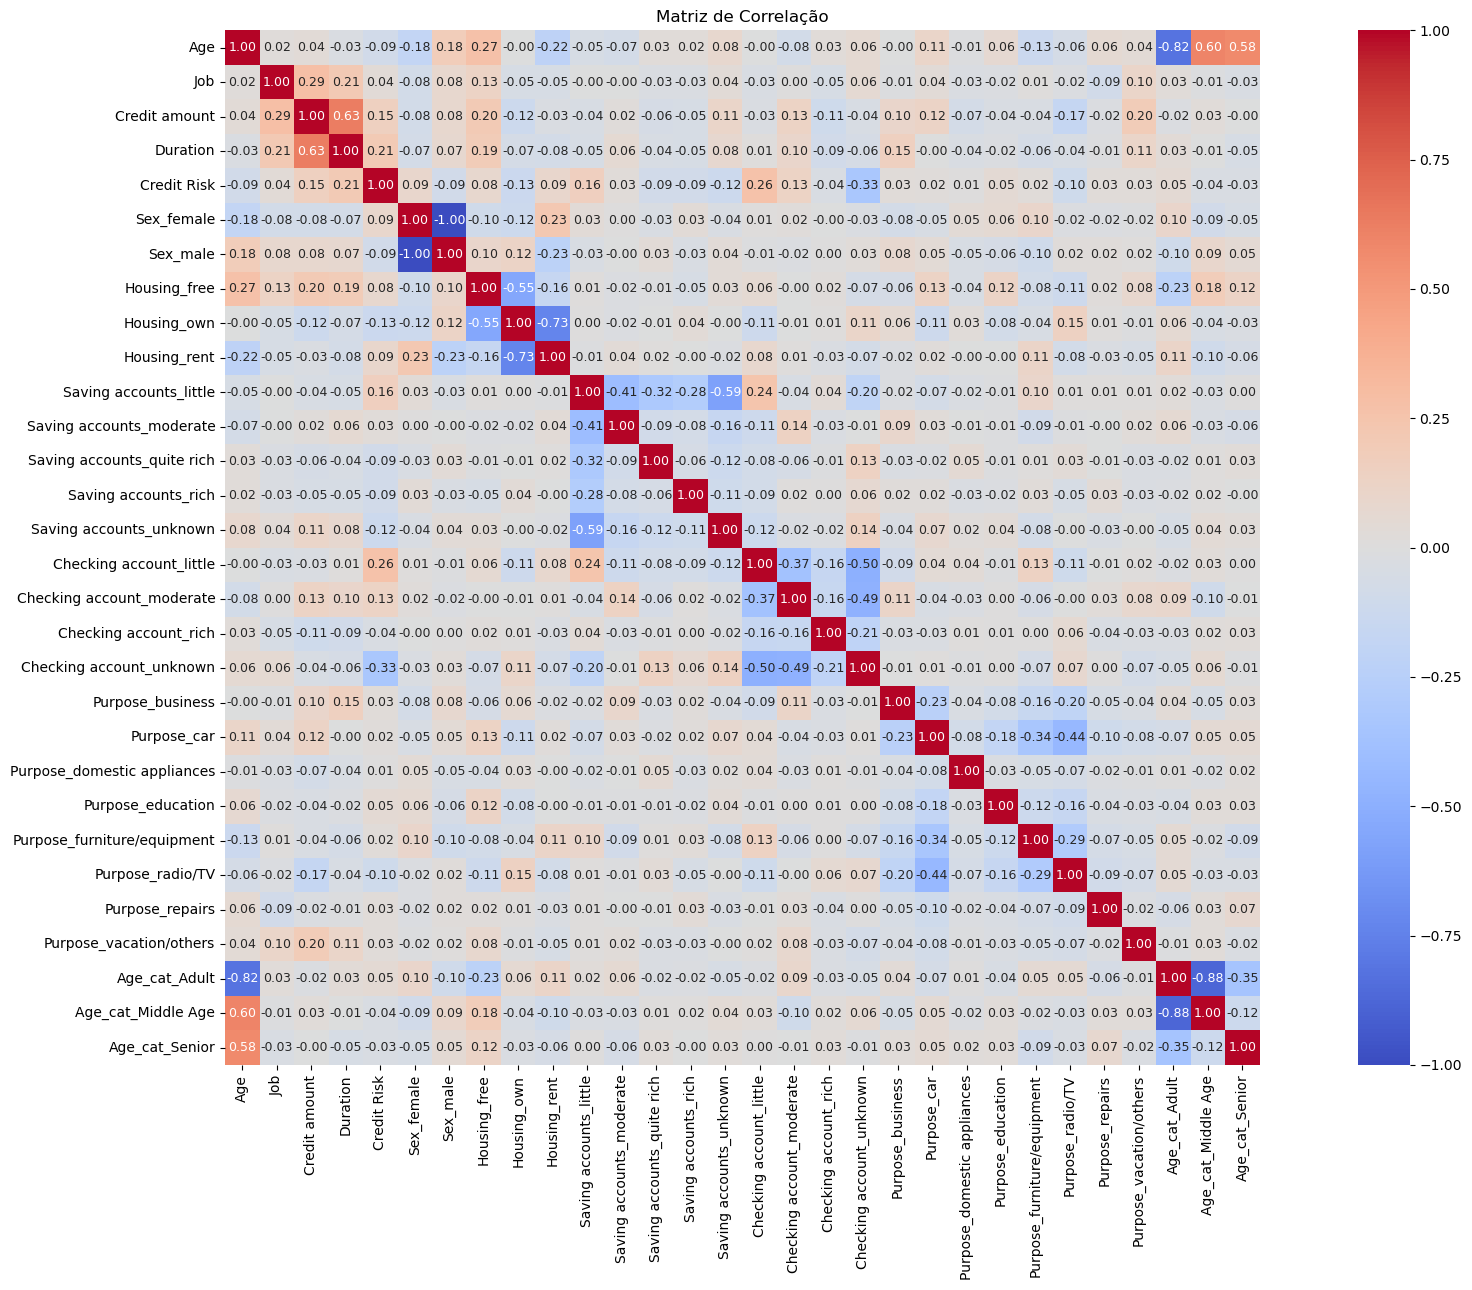

In [86]:
# Criando uma matriz de correlação do DataFrame com variáveis dummy
correlation_matrix = df_dummies.corr()
plt.figure(figsize=(20, 13))
sns.heatmap(correlation_matrix, annot=True, square=True, cmap='coolwarm', fmt=".2f", annot_kws={"size":9})
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

Observando a matriz de correlação, percebemos que não há uma correlação forte entre as características e a varável alvo.

### 3.1. Modelagem preditiva com Random Forest

Escolhi o modelo Random Forest, pois lida bem com dados mistos (numéricos e categóricos) e não exige normalização rigorosa dos dados. Além disso, ele captura relações não-lineares e interações entre variáveis, o que é útil quando a correlação linear não é forte.

In [90]:
# Importando bibliotecas para modelagem preditiva
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Removendo a coluna "Age_cat" do DataFrame
df = df.drop(columns=["Age_cat"], axis=1)

# Codificando variáveis categóricas usando Label Encoding
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Salvando o encoder se precisar inverter depois

display(df.head())



,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,67,1,2,1,4,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,2
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,2


In [100]:
# Separando características (X) e variável alvo (y)
X = df.drop('Credit Risk', axis=1)
y = df['Credit Risk']

# Dividindo em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Criando e treinando o modelo Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
model.fit(X_train, y_train)

# Fazendo previsões
y_pred = model.predict(X_test)

In [101]:
# Avaliando o modelo
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.81      0.84      0.83       200
           2       0.60      0.55      0.57        87

    accuracy                           0.75       287
   macro avg       0.71      0.70      0.70       287
weighted avg       0.75      0.75      0.75       287



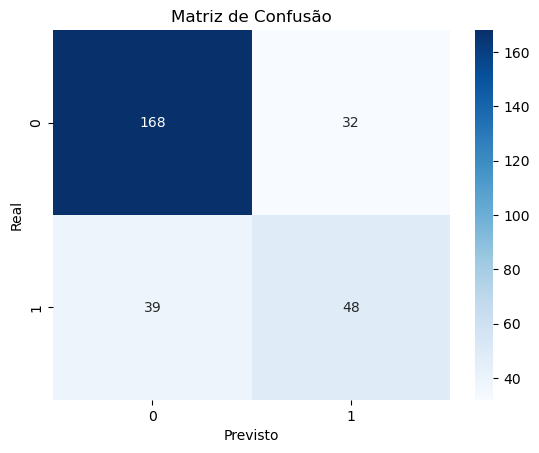

In [102]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()


Observando o relatório de classificação e a matriz de confusão, podemos concluir que:
- O modelo atual apresenta um bom desempenho para identificar clientes com um bom risco de crédito
- Dos 200 clientes bons 168 foram identificados corretamente
- Baixo recall para a classe dos clientes com risco de crédito ruim. O modelo acertou 48 de um total de 87 clientes ruins
- Dos 87 clientes ruins, 39 passaramm despercebidos pelo moedelo
- 40% dos clientes classificados como ruins são na verdade bons (precisão de 60%)
- Acurácia geral aceitável. Melhor que um modelo que sempre chuta "Bom" (70%). 


Importância das Variáveis:
            Feature  Importance
6     Credit amount    0.236612
0               Age    0.171081
5  Checking account    0.150237
7          Duration    0.149956
4   Saving accounts    0.080152
8           Purpose    0.080014
2               Job    0.052787
3           Housing    0.046764
1               Sex    0.032397


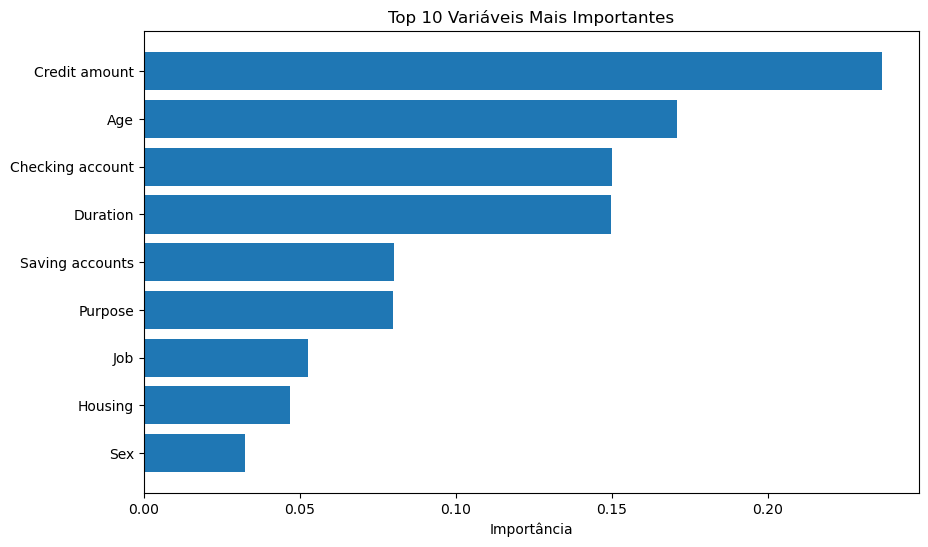

In [98]:
# Importância das variáveis
importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nImportância das Variáveis:")
print(importance_df.head(10))

# Plotando importância
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel('Importância')
plt.title('Top 10 Variáveis Mais Importantes')
plt.gca().invert_yaxis()
plt.show()

Ao analisar a importância das variáveis, é possível concluir que:

**Variável dominante:**

- Credit amount (23.7%) é claramente a variável mais influente. Isso faz sentido no contexto de crédito, pois valores maiores naturalmente representam maior risco potencial.

**Grupo de moderada importância (53-59% combinado):**

- Age (17.1%): Fator demográfico relevante, possivelmente refletindo estabilidade financeira relacionada à idade.
- Checking account (15.0%): Situação da conta corrente é um forte indicador de saúde financeira imediata.
- Duration (15.0%): Prazo do empréstimo influencia risco - prazos mais longos podem aumentar incerteza.

**Variáveis com contribuição secundária (8-10%):**

- Saving accounts e Purpose têm importância similar (~8%), sugerindo que reservas financeiras e finalidade do empréstimo têm algum peso, mas menor.

**Variáveis menos influentes (<6%):**

- Job, Housing e Sex são as menos importantes neste modelo específico, indicando que, nesta modelagem, essas características tiveram menor poder preditivo.

In [99]:
# Validação cruzada para verificar estabilidade do modelo
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"\nAcurácia com Validação Cruzada (5 folds): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Acurácia com Validação Cruzada (5 folds): 0.7443 (+/- 0.0440)


O modelo teve desempenho consistente em torno de 74.43%, com variação máxima de:
- Pior caso: 74.43% - 4.40% = 70.03%
- Melhor caso: 74.43% + 4.40% = 78.83%

## 4. Conclusão

### Conclusão do Projeto: Predição de Risco de Crédito

Este projeto teve como objetivo principal o desenvolvimento de um modelo capaz de identificar o risco de inadimplência de clientes, classificando-os como "bons" ou "maus" pagadores. Através de um fluxo completo de ciência de dados, foi possível extrair os seguintes insights e resultados:

#### 1. Perfil dos Clientes e Insights da Análise Exploratória (EDA)

* **Demografia e Ocupação**: A base de dados revelou um perfil predominantemente jovem (até 42 anos), do sexo masculino (656 homens contra 298 mulheres) e com ocupações classificadas como "skilled" (trabalhador qualificado).
* **Comportamento Financeiro**: A maioria dos clientes possui poupança limitada (categoria "little") e muitos não possuem conta corrente registrada.
* **Fatores de Risco**:
* **Habitação**: Clientes com casa própria apresentam uma relação mais positiva com o crédito, com cerca de 73,5% de risco positivo.
* **Duração do Empréstimo**: Contratos de curto prazo (5 a 9 meses) possuem as menores taxas de inadimplência (aprox. 18%), enquanto prazos mais longos tendem a aumentar a proporção de inadimplentes.
* **Finalidade**: Os motivos mais frequentes para solicitação de crédito são a compra de carros, seguidos por aparelhos de rádio/TV e móveis.



#### 2. Performance do Modelo de Machine Learning

Para a predição, foi utilizado o algoritmo **Random Forest** após o tratamento de variáveis categóricas (criação de variáveis *dummy*).

* **Acurácia**: O modelo apresentou uma acurácia média de **74,43%** em validação cruzada (5 folds).
* **Estabilidade**: O desempenho mostrou-se estável, com um desvio padrão de 4,40%, variando entre 70,03% no pior caso e 78,83% no melhor cenário.
* **Importância das Variáveis**: Notou-se que características como sexo e finalidade do crédito tiveram menor poder preditivo nesta modelagem específica.

#### 3. Considerações Finais

O modelo desenvolvido oferece uma base sólida para a tomada de decisão de crédito, superando a barreira dos 74% de precisão geral. Os resultados demonstram que variáveis comportamentais (como tipo de habitação e duração do contrato) são cruciais para entender o risco. Como próximos passos para evolução do projeto, poderiam ser exploradas técnicas de balanceamento de classes ou o ajuste de hiperparâmetros para tentar elevar a acurácia do modelo.